In [1]:
import math
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(42)

RELATIVE_CHANGE = True

# 1 day = 6.5 hours
INPUT_LENGTH = 91
OUTPUT_LENGTH = 26

# Vanilla, Patch, StockGPT
transformer_type = "Patch"

In [2]:
# tickers = [
#     "AAPL", "AMZN", "META", "MSFT", "GOOG", "NVDA",
#     "TSLA", "ORCL", "WMT", "JPM", "LLY", "NFLX",
#     "MA", "XOM", "JNJ", "PLTR", "COST", "HD", "BAC",
#     "AMD", "PG", "UNH", "GE", "CVX", "KO", "CSCO",
#     "TMUS", "IBM", "AXP", "CRM", "MCD", "MU", "PEP"
# ]

tickers = [
    "AAPL", "AMZN", "META", "MSFT", "GOOG", "NVDA",
]

def get_data(tick, length="730d", interval="1d"):
    data = yf.download(tick, period=length, interval=interval, auto_adjust=True, progress=False)

    close = np.array(data["Close"]).flatten()
    open = np.array(data["Open"]).flatten()
    high = np.array(data["High"]).flatten()
    low = np.array(data["Low"]).flatten()

    ticker_df = pd.DataFrame({
        tick+"_open": open,
        tick+"_high": high,
        tick+"_low": low,
        tick+"_close": close,
    }, index=data.index)

    return ticker_df

def get_full_history(length="730d", interval="1h"):
    data_frames = []

    for symbol in tickers:
        df = get_data(symbol, length, interval)
        data_frames.append(df)

    # Combine all ticker frames
    df = pd.concat(data_frames, axis=1)

    # Replace infinite values with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Remove rows with NaN
    df.dropna(inplace=True)

    return df

df = get_full_history()

In [3]:
df.head()

,AAPL_open,AAPL_high,AAPL_low,AAPL_close,AMZN_open,AMZN_high,AMZN_low,AMZN_close,META_open,META_high,...,MSFT_low,MSFT_close,GOOG_open,GOOG_high,GOOG_low,GOOG_close,NVDA_open,NVDA_high,NVDA_low,NVDA_close
Datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-12 14:30:00+00:00,133.880005,134.259995,131.440002,132.970306,96.930000,97.190002,93.500000,95.360001,133.440002,134.500000,...,233.559998,238.179993,92.400002,92.620003,90.570000,92.279999,16.10000,16.226000,15.492000,15.960650
2023-01-12 15:30:00+00:00,132.979996,133.429993,131.990005,132.414993,95.360001,95.510002,94.099998,94.730003,133.939499,135.589996,...,236.380005,238.130005,92.275002,92.529999,91.230003,91.729897,15.96037,16.077999,15.810000,15.955000
2023-01-12 16:30:00+00:00,132.419998,134.085007,132.070007,134.009995,94.750000,95.620003,94.440002,95.580002,135.470001,136.750000,...,237.210007,239.220001,91.730003,92.250000,91.437897,92.199997,15.95800,16.348000,15.907001,16.344999
2023-01-12 17:30:00+00:00,134.009995,134.220001,132.759995,132.809998,95.580002,95.870003,94.730003,94.820000,136.710007,136.869904,...,238.070007,238.490005,92.199997,92.339996,91.540001,91.620003,16.34590,16.507999,16.322050,16.362000
2023-01-12 18:30:00+00:00,132.800003,134.190002,132.419998,133.197495,94.820000,95.760002,94.580002,95.349998,135.960007,137.558899,...,237.630005,238.750000,91.610001,92.419998,91.360001,92.139999,16.36100,16.636999,16.292999,16.541651


In [4]:
# Sequence the full dataframe
def sequence_dataframe(df, relative_change=False):
    sequences, labels = [], []

    if relative_change:
        for i in range(len(df) - (INPUT_LENGTH + OUTPUT_LENGTH) - 1):
            sequences.append(df.iloc[i:i+INPUT_LENGTH+1].values)
            labels.append(df.iloc[i+INPUT_LENGTH:i+INPUT_LENGTH+OUTPUT_LENGTH+1])
    else:
        for i in range(len(df) - (INPUT_LENGTH + OUTPUT_LENGTH)):
            sequences.append(df.iloc[i:i+INPUT_LENGTH].values)
            labels.append(df.iloc[i+INPUT_LENGTH:i+INPUT_LENGTH+OUTPUT_LENGTH].values)

    return np.array(sequences), np.array(labels)

sequences, sequence_labels = sequence_dataframe(df, RELATIVE_CHANGE)

# Split
train_index = int(len(sequences) * 0.9)
train_sequences = sequences[:train_index]
train_labels = sequence_labels[:train_index]

other_sequences = sequences[train_index:]
other_labels = sequence_labels[train_index:]

# Split again
index = int(len(other_sequences) * 0.5)
validation_sequences = other_sequences[:index]
validation_labels = other_labels[:index]

test_sequences = other_sequences[index:]
test_labels = other_labels[index:]

In [5]:
def relative_change(sequences):
    result = sequences.copy()

    for i in range(sequences.shape[0]):
        for j in range(1, sequences.shape[1]):
            result[i, j, :] = (sequences[i, j, :] - sequences[i, j-1, :]) / sequences[i, j-1, :]

    return result[:, 1:, :]

if RELATIVE_CHANGE:
    train_sequences = relative_change(train_sequences)
    train_labels = relative_change(train_labels)

    validation_sequences = relative_change(validation_sequences)
    validation_labels = relative_change(validation_labels)

    test_sequences = relative_change(test_sequences)
    test_labels = relative_change(test_labels)

In [6]:
def normalize_per_window_per_stock(x):
    x_stocks = x.reshape(x.shape[0], x.shape[1], len(tickers), 4)

    mean = x_stocks.mean(axis=1, keepdims=True)
    stdev = x_stocks.std(axis=1, keepdims=True) + 1e-6

    x_norm = (x_stocks - mean) / stdev

    x_norm = x_norm.reshape(x.shape)

    return x_norm, mean, stdev

def denormalize(x_norm, mean, stdev):
    x_norm = x_norm.reshape(x_norm.shape[0], x_norm.shape[1], len(tickers), 4)

    x_raw = x_norm * stdev + mean

    x_raw = x_raw.reshape(x_norm.shape)

    return x_raw

# train_sequences, train_seq_mean, train_seq_std = normalize_per_window_per_stock(train_sequences)
# train_labels, train_label_mean, train_label_std = normalize_per_window_per_stock(train_labels)

# validation_sequences, val_seq_mean, val_seq_std = normalize_per_window_per_stock(validation_sequences)
# validation_labels, val_label_mean, val_seq_std = normalize_per_window_per_stock(validation_labels)

# test_sequences, test_seq_mean, test_seq_std = normalize_per_window_per_stock(test_sequences)
# test_labels, test_label_mean, test_label_std = normalize_per_window_per_stock(test_labels)

In [7]:
train_mean = np.mean(train_sequences)
train_std = np.std(train_sequences)

train_sequences = (train_sequences - train_mean) / train_std
train_labels = (train_labels - train_mean) / train_std

validation_sequences = (validation_sequences - train_mean) / train_std
validation_labels = (validation_labels - train_mean) / train_std

test_sequences = (test_sequences - train_mean) / train_std
test_labels = (test_labels - train_mean) / train_std

# Transformer

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        # Ensure that the model dimension (d_model) is divisible by the number of heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        # Initialize dimensions
        self.d_model = d_model # Model's dimension
        self.num_heads = num_heads # Number of attention heads
        self.d_k = d_model // num_heads # Dimension of each head's key, query, and value

        # Linear layers for transforming inputs
        self.W_q = nn.Linear(d_model, d_model) # Query transformation
        self.W_k = nn.Linear(d_model, d_model) # Key transformation
        self.W_v = nn.Linear(d_model, d_model) # Value transformation
        self.W_o = nn.Linear(d_model, d_model) # Output transformation

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Calculate attention scores
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply mask if provided (useful for preventing attention to certain parts like padding)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == float('-inf'), float('-inf'))

        # Softmax is applied to obtain attention probabilities
        attn_probs = torch.softmax(attn_scores, dim=-1)

        # Multiply by values to obtain the final output
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        # Reshape the input to have num_heads for multi-head attention
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        # Combine the multiple heads back to original shape
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        # Apply linear transformations and split heads
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        # Perform scaled dot-product attention
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)

        # Combine heads and apply output transformation
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [9]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [11]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)  # Prevents overfitting

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [12]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

In [13]:
class DecoderOnlyLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderOnlyLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

In [14]:
class VanillaTransformer(nn.Module):
    def __init__(self, input_size, output_size, feature_length, d_model, num_heads, num_layers, d_ff, dropout):
        super(VanillaTransformer, self).__init__()
        # Use Linear layers instead of Embedding for continuous numerical input
        self.encoder_input_layer = nn.Linear(input_size, d_model)
        self.decoder_input_layer = nn.Linear(input_size, d_model)

        self.positional_encoding = PositionalEncoding(d_model, feature_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, output_size)
        self.dropout = nn.Dropout(dropout)

        self.padding_mask = ()

    def generate_mask(self, size):
        mask = torch.triu(torch.ones(size, size), diagonal=1).bool()
        mask = mask.float().masked_fill(mask == 1, float('-inf'))
        return mask

    def forward(self, src, tgt):
        # Apply positional encoding and dropout
        # (Randomly zeroes elements --> prevents overfitting)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_input_layer(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_input_layer(tgt)))

        # Decoder Mask
        tgt_mask = self.generate_mask(tgt.size(1)).to(device)

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            # Pass None for the mask as it's not used
            enc_output = enc_layer(enc_output, None)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            # Pass None for embed mask for now
            dec_output = dec_layer(dec_output, enc_output, None, tgt_mask)

        output = self.fc(dec_output)
        return output

In [15]:
class PatchTransformer(nn.Module):
    def __init__(self, input_size, output_size, feature_length, d_model, num_heads, num_layers, d_ff, dropout):
        super(PatchTransformer, self).__init__()

        self.embedding = nn.Linear(input_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, input_size)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # Apply positional encoding and dropout
        # (Randomly zeroes elements --> prevents overfitting)
        src = src.permute(0, 2, 1)
        src_embedded = self.dropout(self.positional_encoding(self.embedding(src)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, None)

        output = self.fc(enc_output)
        return output.permute(0, 2, 1)

In [16]:
class StockGPT(nn.Module):
    def __init__(self, input_size, output_size, feature_length, d_model, num_heads, num_layers, d_ff, dropout):
        super(StockGPT, self).__init__()

        self.embedding = nn.Linear(feature_length, d_model)
        self.positional_encoding = PositionalEncoding(d_model, input_size)
        self.decoder_layers = nn.ModuleList([DecoderOnlyLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, feature_length)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, size):
        mask = torch.triu(torch.ones(size, size), diagonal=1).bool()
        mask = mask.float().masked_fill(mask == 1, float('-inf'))
        return mask

    def forward(self, tgt):
        tgt_embedded = self.dropout(self.positional_encoding(self.embedding(tgt)))

        # Decoder Mask
        tgt_mask = self.generate_mask(tgt.size(1)).to(device)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, tgt_mask)

        output = self.fc(dec_output)
        return output

# Base Transformer Train

In [17]:
# Convert numpy arrays to PyTorch tensors
src_data = torch.tensor(train_sequences).float().to(device)
tgt_data = torch.tensor(train_labels).float().to(device)

# Input Parameters
input_size = INPUT_LENGTH
output_size = OUTPUT_LENGTH
feature_size = train_sequences.shape[-1]

# Parameters
d_model = 512
num_heads = 8
num_layers = 8
d_ff = 2048
dropout = 0.1
epoch_num = 100

# Initialize the Transformer with the correct input size
if transformer_type == "Patch":
    transformer = PatchTransformer(input_size, output_size, feature_size, d_model, num_heads, num_layers, d_ff, dropout).to(device)
elif transformer_type == "Vanilla":
    transformer = VanillaTransformer(input_size, output_size, feature_size, d_model, num_heads, num_layers, d_ff, dropout).to(device)
elif transformer_type == "StockGPT":
    transformer = StockGPT(input_size, output_size, feature_size, d_model, num_heads, num_layers, d_ff, dropout).to(device)

In [18]:
criterion = nn.MSELoss()
optimizer = optim.Adam(transformer.parameters(), lr=0.0001)

train_loader = DataLoader(TensorDataset(src_data, tgt_data), batch_size=64, shuffle=False)

transformer.train()
for epoch in range(epoch_num):
    for x, y in train_loader:
        optimizer.zero_grad()

        x = x.to(device).float()    # Input data
        y = y.to(device).float()    # Target

        if transformer_type == "Patch":
            # PatchTransformer
            output = transformer(x)
            loss = criterion(output, y)

        elif transformer_type == "Vanilla":
            # Vanilla Transformer
            output = transformer(x, y[:, :-1, :])
            loss = criterion(output, y[:, 1:, :])

        elif transformer_type == "StockGPT":
            # StockGPT
            output = transformer(y[:, :-1, :])
            loss = criterion(output, y[:, 1:, :])

        loss.backward()
        optimizer.step()

    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 0.4802238345146179
Epoch: 2, Loss: 0.47691547870635986
Epoch: 3, Loss: 0.46600183844566345
Epoch: 4, Loss: 0.45688822865486145
Epoch: 5, Loss: 0.46045488119125366
Epoch: 6, Loss: 0.4515450596809387
Epoch: 7, Loss: 0.44477975368499756
Epoch: 8, Loss: 0.45439910888671875
Epoch: 9, Loss: 0.43252453207969666
Epoch: 10, Loss: 0.4464598596096039
Epoch: 11, Loss: 0.4389691650867462
Epoch: 12, Loss: 0.44243231415748596
Epoch: 13, Loss: 0.47370854020118713
Epoch: 14, Loss: 0.4623427987098694
Epoch: 15, Loss: 0.43739330768585205
Epoch: 16, Loss: 0.40969645977020264
Epoch: 17, Loss: 0.39676663279533386
Epoch: 18, Loss: 0.38275134563446045
Epoch: 19, Loss: 0.38587328791618347
Epoch: 20, Loss: 0.38227733969688416
Epoch: 21, Loss: 0.3840572237968445
Epoch: 22, Loss: 0.373553067445755
Epoch: 23, Loss: 0.36379653215408325
Epoch: 24, Loss: 0.3581792116165161
Epoch: 25, Loss: 0.36050325632095337
Epoch: 26, Loss: 0.3453258275985718
Epoch: 27, Loss: 0.3545253574848175
Epoch: 28, Loss: 0.34

In [19]:
val_loader = DataLoader(TensorDataset(torch.tensor(validation_sequences).float().to(device), torch.tensor(validation_labels).float().to(device)), batch_size=64, shuffle=False)

transformer.eval()

with torch.no_grad():
    val_loss = 0.0
    for x, y in val_loader: # Iterate over the validation data loader
        x = x.to(device).float()
        y = y.to(device).float()

        if transformer_type == "Patch":
            # PatchTransformer
            val_output = transformer(x)
            val_loss += criterion(val_output, y).item()

        elif transformer_type == "Vanilla":
            # VanillaTransformer
            val_output = transformer(x, y[:, :-1, :])
            val_loss += criterion(val_output, y[:, 1:, :]).item()

        elif transformer_type == "StockGPT":
            # StockGPT
            val_output = transformer(y[:, :-1, :])
            val_loss += criterion(val_output, y[:, 1:, :]).item()

    # Calculate average validation loss
    val_loss /= len(val_loader)
    print(f"Validation Loss: {val_loss}")

Validation Loss: 0.6839383989572525


In [20]:
def non_autoregressive_prediction(model, input_data):
    model.eval()

    with torch.inference_mode():
        return model(input_data).cpu().numpy()

def autoregressive_prediction(model, input_data):
    model.eval()

    device = next(model.parameters()).device
    input_data = input_data.to(device)

    with torch.inference_mode():
        tgt = input_data[:, -1:, :].clone()

        preds = []
        for _ in range(OUTPUT_LENGTH):
            if transformer_type == "Vanilla":
                out = model(input_data, tgt)
            else:
                out = model(tgt)

            next_step = out[:, -1:, :]
            preds.append(next_step)
            tgt = torch.cat([tgt, next_step], dim=1)

        preds = torch.cat(preds, dim=1)
        return preds.cpu().numpy()

def MSE(pred, actual):
    return np.mean((actual - pred) ** 2)

def MAE(pred, actual):
    return np.mean(np.abs(actual - pred))

def RSquared(pred, actual):
    real_mean = np.mean(actual)
    deviation = np.square(actual - real_mean)
    ss_tot = np.sum(deviation)

    errors = np.square(actual - pred)
    ss_res = np.sum(errors)

    return 1 - ss_res / ss_tot

In [21]:
transformer.eval()

test_src_data = torch.tensor(test_sequences).float().to(device)

if transformer_type == "Patch":
    # PatchTransformer
    predicted = non_autoregressive_prediction(transformer, test_src_data.clone())
elif transformer_type == "Vanilla":
    # VanillaTransformer
    predicted = autoregressive_prediction(transformer, test_src_data.clone())
elif transformer_type == "StockGPT":
    # StockGPT
    predicted = autoregressive_prediction(transformer, test_src_data.clone())
actual_plot_data = test_labels.copy()

# Calculate Mean and Median MSE over all sequences
stats = []
for x in range(actual_plot_data.shape[0]):
    stats.append(MSE(predicted[x, :, 3], actual_plot_data[x, :, 3]))
mean_mse = np.mean(stats)
median_mse = np.median(stats)

print(f"Mean MSE: {mean_mse}")
print(f"Median MSE: {median_mse}")

r2_stats = []
for x in range(actual_plot_data.shape[0]):
    r2_stats.append(RSquared(predicted[x, :, 3], actual_plot_data[x, :, 3]))
mean_rsquared = np.mean(r2_stats)
median_rsquared = np.median(r2_stats)

print(f"Mean R^2: {mean_rsquared}")
print(f"Median R^2: {median_rsquared}")

Mean MSE: 0.47103952281567757
Median MSE: 0.3928620323294622
Mean R^2: -0.5098598315276377
Median R^2: -0.3869896613189723


# Refiner Model

In [22]:
class Refiner(nn.Module):
    def __init__(self, input_size, output_size, d_model=32, num_layers=3, kernel_size=3):
        super(Refiner, self).__init__()

        in_channels = input_size
        layers = []
        for i in range(num_layers):
            dilation = 2 ** i
            padding = (kernel_size - 1) * dilation // 2

            layers.append(
                nn.Conv1d(
                    in_channels=in_channels,
                    out_channels=d_model,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    padding=padding,
                )
            )
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(d_model))
            in_channels = d_model

        layers.append(
            nn.Conv1d(
                in_channels=d_model,
                out_channels=output_size,
                kernel_size=1,
            )
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

refiner = Refiner(feature_size, feature_size, kernel_size=7).to(device)

In [23]:
criterion = nn.MSELoss()
optimizer = optim.Adam(refiner.parameters(), lr=0.0001)

transformer.eval()
train_loader = DataLoader(TensorDataset(src_data, tgt_data), batch_size=64, shuffle=False)

refiner.train()
for epoch in range(50):
    for x, y in train_loader:
        optimizer.zero_grad()

        x = x.to(device).float()
        y = y.to(device).float()

        if transformer_type == "Patch":
            # PatchTransformer
            predicted = non_autoregressive_prediction(transformer, x)
        elif transformer_type == "Vanilla":
            # VanillaTransformer
            predicted = autoregressive_prediction(transformer, x)
        elif transformer_type == "StockGPT":
            # StockGPT
            predicted = autoregressive_prediction(transformer, x)

        predicted = torch.tensor(predicted).to(device).float().detach()

        predicted = predicted.permute(0, 2, 1)
        y = y.permute(0, 2, 1)

        residual_target = y - predicted
        residual_pred = refiner(predicted)

        loss = criterion(residual_pred, residual_target)
        loss.backward()
        optimizer.step()

    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 0.3121401369571686
Epoch: 2, Loss: 0.23044535517692566
Epoch: 3, Loss: 0.1846391260623932
Epoch: 4, Loss: 0.15805931389331818
Epoch: 5, Loss: 0.1419561803340912
Epoch: 6, Loss: 0.13180366158485413
Epoch: 7, Loss: 0.12506717443466187
Epoch: 8, Loss: 0.12035375088453293
Epoch: 9, Loss: 0.1170177310705185
Epoch: 10, Loss: 0.11463629454374313
Epoch: 11, Loss: 0.11291854828596115
Epoch: 12, Loss: 0.11166071891784668
Epoch: 13, Loss: 0.110739566385746
Epoch: 14, Loss: 0.11005282402038574
Epoch: 15, Loss: 0.1095159500837326
Epoch: 16, Loss: 0.10911174863576889
Epoch: 17, Loss: 0.10876620560884476
Epoch: 18, Loss: 0.10848046839237213
Epoch: 19, Loss: 0.10824435204267502
Epoch: 20, Loss: 0.10805855691432953
Epoch: 21, Loss: 0.10787333548069
Epoch: 22, Loss: 0.1076742559671402
Epoch: 23, Loss: 0.10749427229166031
Epoch: 24, Loss: 0.10731477290391922
Epoch: 25, Loss: 0.10713514685630798
Epoch: 26, Loss: 0.10693293809890747
Epoch: 27, Loss: 0.10675239562988281
Epoch: 28, Loss: 0.10

In [24]:
# Refined prediction functions to use refiner model

def non_autoregressive_prediction(model, input_data):
    with torch.inference_mode():
        out = model(input_data)

        residual = refiner(out.permute(0,2,1))
        out += residual.permute(0,2,1)

        return out.cpu().numpy()

def autoregressive_prediction(model, input_data):
    device = next(model.parameters()).device
    input_data = input_data.to(device)

    with torch.inference_mode():
        tgt = input_data[:, -1:, :].clone()

        preds = []
        for _ in range(OUTPUT_LENGTH):
            if transformer_type == "Vanilla":
                out = model(input_data, tgt)
            else:
                out = model(tgt)

            next_step = out[:, -1:, :]
            preds.append(next_step)
            tgt = torch.cat([tgt, next_step], dim=1)

        preds = torch.cat(preds, dim=1)

        residual = refiner(preds)
        preds += residual

        return preds.cpu().numpy()

In [25]:
transformer.eval()
refiner.eval()

test_src_data = torch.tensor(test_sequences).float().to(device)

if transformer_type == "Patch":
    # PatchTransformer
    predicted = non_autoregressive_prediction(transformer, test_src_data.clone())
elif transformer_type == "Vanilla":
    # VanillaTransformer
    predicted = autoregressive_prediction(transformer, test_src_data.clone())
elif transformer_type == "StockGPT":
    # StockGPT
    predicted = autoregressive_prediction(transformer, test_src_data.clone())
actual_plot_data = test_labels.copy()

# Calculate Mean and Median MSE over all sequences
stats = []
for x in range(actual_plot_data.shape[0]):
    stats.append(MSE(predicted[x, :, 3], actual_plot_data[x, :, 3]))
mean_mse = np.mean(stats)
median_mse = np.median(stats)

print(f"Mean MSE: {mean_mse}")
print(f"Median MSE: {median_mse}")

r2_stats = []
for x in range(actual_plot_data.shape[0]):
    r2_stats.append(RSquared(predicted[x, :, 3], actual_plot_data[x, :, 3]))
mean_rsquared = np.mean(r2_stats)
median_rsquared = np.median(r2_stats)

print(f"Mean R^2: {mean_rsquared}")
print(f"Median R^2: {median_rsquared}")

Mean MSE: 0.456603172835752
Median MSE: 0.38234117186347016
Mean R^2: -0.4609761689125487
Median R^2: -0.35855426617796415


In [26]:
new_refiner = Refiner(feature_size, feature_size, kernel_size=5).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(new_refiner.parameters(), lr=0.0001)

transformer.eval()
refiner.eval()
train_loader = DataLoader(TensorDataset(src_data, tgt_data), batch_size=64, shuffle=False)

new_refiner.train()
for epoch in range(50):
    for x, y in train_loader:
        optimizer.zero_grad()

        x = x.to(device).float()
        y = y.to(device).float()

        if transformer_type == "Patch":
            # PatchTransformer
            predicted = non_autoregressive_prediction(transformer, x)
        elif transformer_type == "Vanilla":
            # VanillaTransformer
            predicted = autoregressive_prediction(transformer, x)
        elif transformer_type == "StockGPT":
            # StockGPT
            predicted = autoregressive_prediction(transformer, x)

        predicted = torch.tensor(predicted).to(device).float().detach()

        predicted = predicted.permute(0, 2, 1)
        y = y.permute(0, 2, 1)

        predicted = new_refiner(predicted)

        loss = criterion(predicted, y)

        loss.backward()
        optimizer.step()

    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 0.6022851467132568
Epoch: 2, Loss: 0.485049843788147
Epoch: 3, Loss: 0.41538503766059875
Epoch: 4, Loss: 0.3781364858150482
Epoch: 5, Loss: 0.3549615144729614
Epoch: 6, Loss: 0.3373183608055115
Epoch: 7, Loss: 0.32214489579200745
Epoch: 8, Loss: 0.30841097235679626
Epoch: 9, Loss: 0.29542839527130127
Epoch: 10, Loss: 0.28321000933647156
Epoch: 11, Loss: 0.27218446135520935
Epoch: 12, Loss: 0.26225224137306213
Epoch: 13, Loss: 0.25325629115104675
Epoch: 14, Loss: 0.24502664804458618
Epoch: 15, Loss: 0.23762395977973938
Epoch: 16, Loss: 0.23110011219978333
Epoch: 17, Loss: 0.22523802518844604
Epoch: 18, Loss: 0.22001461684703827
Epoch: 19, Loss: 0.2153199464082718
Epoch: 20, Loss: 0.2112208753824234
Epoch: 21, Loss: 0.2074829638004303
Epoch: 22, Loss: 0.2041139453649521
Epoch: 23, Loss: 0.20107363164424896
Epoch: 24, Loss: 0.1983306109905243
Epoch: 25, Loss: 0.19574320316314697
Epoch: 26, Loss: 0.1933337301015854
Epoch: 27, Loss: 0.19106513261795044
Epoch: 28, Loss: 0.188

# Testing

In [27]:
# Refined prediction functions to use refiner model

def non_autoregressive_prediction(model, input_data):
    model.eval()
    refiner.eval()

    with torch.inference_mode():
        out = model(input_data)

        residual = refiner(out.permute(0,2,1))
        out += residual.permute(0,2,1)
        out = new_refiner(out.permute(0,2,1))
        out = out.permute(0, 2, 1)

        return out.cpu().numpy()

def autoregressive_prediction(model, input_data):
    model.eval()
    refiner.eval()

    device = next(model.parameters()).device
    input_data = input_data.to(device)

    with torch.inference_mode():
        tgt = input_data[:, -1:, :].clone()

        preds = []
        for _ in range(OUTPUT_LENGTH):
            if transformer_type == "Vanilla":
                out = model(input_data, tgt)
            else:
                out = model(tgt)

            next_step = out[:, -1:, :]
            preds.append(next_step)
            tgt = torch.cat([tgt, next_step], dim=1)

        preds = torch.cat(preds, dim=1)

        residual = refiner(preds)
        preds += residual

        return preds.cpu().numpy()

In [28]:
transformer.eval()
refiner.eval()
new_refiner.eval()

test_src_data = torch.tensor(test_sequences).float().to(device)

if transformer_type == "Patch":
    # PatchTransformer
    predicted = non_autoregressive_prediction(transformer, test_src_data.clone())
elif transformer_type == "Vanilla":
    # VanillaTransformer
    predicted = autoregressive_prediction(transformer, test_src_data.clone())
elif transformer_type == "StockGPT":
    # StockGPT
    predicted = autoregressive_prediction(transformer, test_src_data.clone())
actual_plot_data = test_labels.copy()

# Calculate Mean and Median MSE over all sequences
stats = []
for x in range(actual_plot_data.shape[0]):
    stats.append(MSE(predicted[x, :, 3], actual_plot_data[x, :, 3]))
mean_mse = np.mean(stats)
median_mse = np.median(stats)

print(f"Mean MSE: {mean_mse}")
print(f"Median MSE: {median_mse}")

r2_stats = []
for x in range(actual_plot_data.shape[0]):
    r2_stats.append(RSquared(predicted[x, :, 3], actual_plot_data[x, :, 3]))
mean_rsquared = np.mean(r2_stats)
median_rsquared = np.median(r2_stats)

print(f"Mean R^2: {mean_rsquared}")
print(f"Median R^2: {median_rsquared}")

Mean MSE: 0.4326153141745021
Median MSE: 0.3491731056638171
Mean R^2: -0.34378125301473633
Median R^2: -0.27594997434124147


MSE: 0.5602234305352751


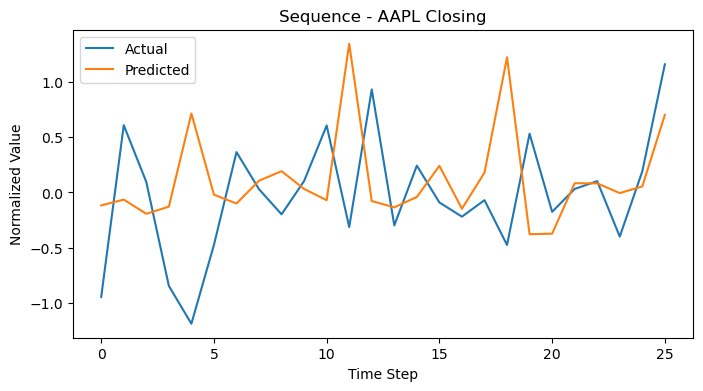

MSE: 0.27233680975065017


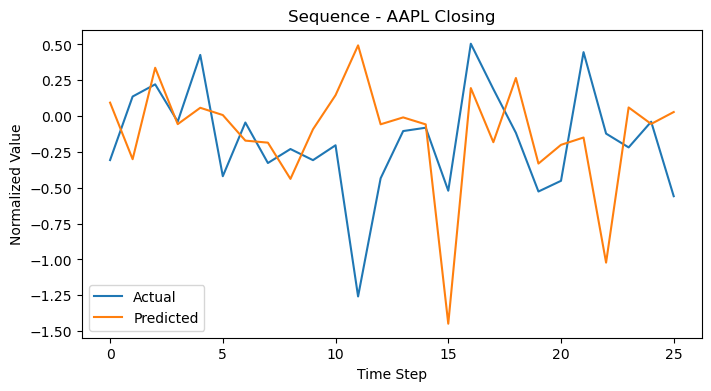

MSE: 0.9589923435647392


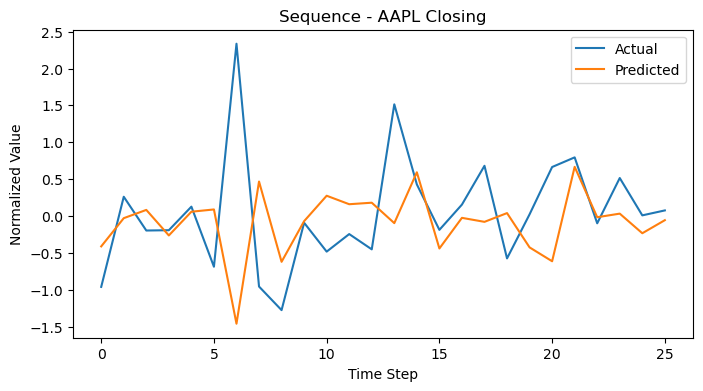

MSE: 0.2763707727230603


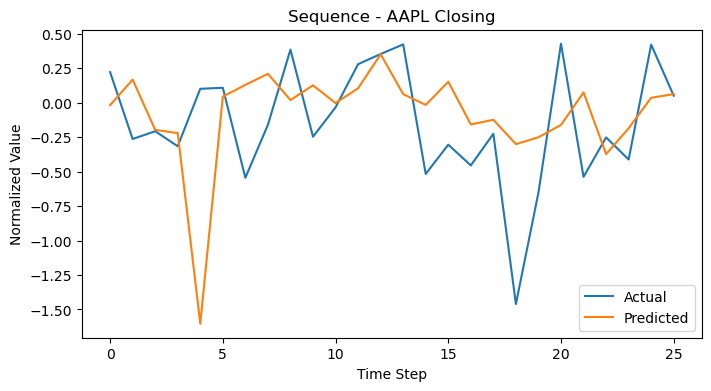

MSE: 0.267676283689308


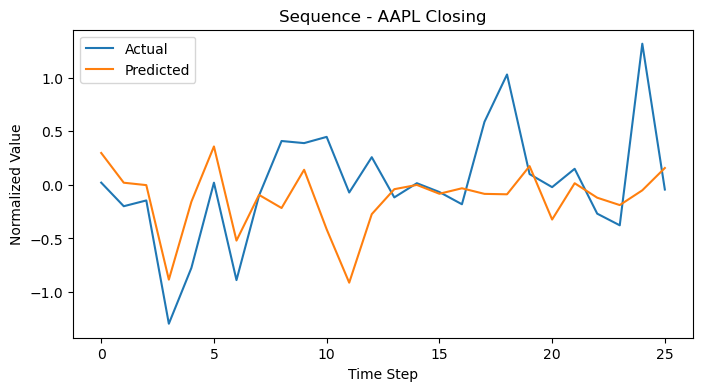

In [29]:
# Plot a few sequences to visualize the predictions
num_plots = 5
for i in range(num_plots):
    plt.figure(figsize=(8, 4))

    x_values = np.arange(OUTPUT_LENGTH)
    p = int(np.random.rand() * actual_plot_data.shape[0])

    print(f"MSE: {MSE(actual_plot_data[p, :, 3], predicted[p, :, 3])}")

    plt.plot(x_values, actual_plot_data[p, :, 3], label='Actual')
    plt.plot(x_values, predicted[p, :, 3], label='Predicted')

    plt.title(f'Sequence - AAPL Closing')
    plt.xlabel('Time Step')
    plt.ylabel('Normalized Value')
    plt.legend()
    plt.show()